## 1. Set up

In [5]:
# Always needed if want to use the local version
%reload_ext autoreload
%autoreload 2

%cd /Users/dunglai/Documents/Việt Dũng/Personal Projects/World Foresight Framework/Data Preparation

/Users/dunglai/Documents/Việt Dũng/Personal Projects/World Foresight Framework/Data Preparation


In [6]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/dunglai/Documents/Việt Dũng/Personal Projects/World Foresight Framework")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Modeling.proxy_config import MIN_DATAPOINTS_PER_PROXY, validate_proxy_config
from Modeling.prepare_data import prepare_modeling_frame
from Modeling.diagnostics import compute_series_diagnostics
from Modeling.forecast_2040 import run_forecast

DATA_PATH = PROJECT_ROOT / "Final Data.xlsx"
MIN_DATAPOINTS = MIN_DATAPOINTS_PER_PROXY

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path exists: {DATA_PATH.exists()}")


Project root: /Users/dunglai/Documents/Việt Dũng/Personal Projects/World Foresight Framework
Data path exists: True


## 2. Load Workbook Sheets

In [7]:
timeseries_df = pd.read_excel(DATA_PATH, sheet_name="Historical Data")
proxy_config_raw = pd.read_excel(DATA_PATH, sheet_name="Model Input - Proxy Info")
proxy_info_df = pd.read_excel(DATA_PATH, sheet_name="Proxy Information")

print("Timeseries rows:", len(timeseries_df))
print("Proxy config rows:", len(proxy_config_raw))
print("Proxy info rows:", len(proxy_info_df))

display(timeseries_df.head(5))
display(proxy_config_raw.head(5))

Timeseries rows: 19192
Proxy config rows: 37
Proxy info rows: 37


,id,proxy_id,market,year,value,labels,metric
0,D1,D1_ARE,ARE,2000,5875.833901,USD (millions),MILLIONS
1,D1,D1_ARE,ARE,2001,5797.957794,USD (millions),MILLIONS
2,D1,D1_ARE,ARE,2002,5354.118448,USD (millions),MILLIONS
3,D1,D1_ARE,ARE,2003,5834.717495,USD (millions),MILLIONS
4,D1,D1_ARE,ARE,2004,6816.882233,USD (millions),MILLIONS


,id,proxy_type,lower_bound,upper_bound,allow_negative,shock_year_policy
0,D1,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT
1,D2,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT
2,D3,BOUNDED,0.0,100.0,False,IGNORE
3,D4,BOUNDED,0.0,100.0,False,DOWNWEIGHT
4,D5,BOUNDED,0.0,1.0,False,IGNORE


## 3. Validate Data Input

In [8]:
proxy_config = validate_proxy_config(
    proxy_config_raw,
    timeseries_df=timeseries_df,
    min_datapoints=MIN_DATAPOINTS,
)

raw_config_ids = set(proxy_config_raw["id"].dropna().astype(str).str.strip())
validated_config_ids = set(proxy_config["id"])
removed_low_datapoint_ids = sorted(raw_config_ids - validated_config_ids)

print("Validated proxy config rows after min datapoint filter:", len(proxy_config))
print("Removed IDs with fewer than", MIN_DATAPOINTS, "usable datapoints:", removed_low_datapoint_ids)
display(proxy_config.head(5))

Validated proxy config rows after min datapoint filter: 37
Removed IDs with fewer than 5 usable datapoints: []


,id,proxy_type,lower_bound,upper_bound,allow_negative,shock_year_policy
0,D1,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT
1,D2,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT
2,D3,BOUNDED,0.0,100.0,False,IGNORE
3,D4,BOUNDED,0.0,100.0,False,DOWNWEIGHT
4,D5,BOUNDED,0.0,1.0,False,IGNORE


In [9]:
input_ids = set(proxy_config_raw["id"].dropna().astype(str).str.strip())
modeling_input_ids = set(proxy_config["id"])
timeseries_ids = set(timeseries_df["id"].dropna().astype(str).str.strip())
info_ids = set(proxy_info_df["id"].dropna().astype(str).str.strip())

check = {
    "raw_input_vs_timeseries": sorted(input_ids - timeseries_ids),
    "timeseries_vs_raw_input": sorted(timeseries_ids - input_ids),
    "raw_input_vs_info": sorted(input_ids - info_ids),
    "info_vs_raw_input": sorted(info_ids - input_ids),
    "removed_by_min_datapoints": sorted(input_ids - modeling_input_ids),
}

# The first four checks should be empty. The last check lists intentionally removed low-evidence IDs.
check

{'raw_input_vs_timeseries': [],
 'timeseries_vs_raw_input': [],
 'raw_input_vs_info': [],
 'info_vs_raw_input': [],
 'removed_by_min_datapoints': []}

In [10]:
# Check whether timeseries data has duplicates across all columns
duplicate_rows = timeseries_df[timeseries_df.duplicated(keep=False)].sort_values(by=list(timeseries_df.columns))

print("Exact duplicate rows:", len(duplicate_rows))
display(duplicate_rows.head(5))

# Summarize duplicate counts by 'id'
duplicate_summary = (
    duplicate_rows.groupby("id")
    .size()
    .reset_index(name="duplicate_row_count")
    .sort_values("duplicate_row_count", ascending=False)
)
display(duplicate_summary)

Exact duplicate rows: 0


,id,proxy_id,market,year,value,labels,metric


,id,duplicate_row_count


## 4. Data Preparation for Modeling

In [11]:
modeling_df = prepare_modeling_frame(
    timeseries_df,
    proxy_config_raw,
    min_datapoints=MIN_DATAPOINTS,
)

print("Prepared modeling rows:", len(modeling_df))
print("Proxy series count:", modeling_df["proxy_id"].nunique())
print("Year range:", int(modeling_df["year"].min()), "to", int(modeling_df["year"].max()))

display(modeling_df.head())

Prepared modeling rows: 19187
Proxy series count: 821
Year range: 2000 to 2025


,id,proxy_id,market,year,value,labels,metric,proxy_type,lower_bound,upper_bound,allow_negative,shock_year_policy,is_shock_year,sample_weight,y
0,D1,D1_ARE,ARE,2000,5875.833901,USD (millions),MILLIONS,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT,False,1.0,8.678773
1,D1,D1_ARE,ARE,2001,5797.957794,USD (millions),MILLIONS,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT,False,1.0,8.665433
2,D1,D1_ARE,ARE,2002,5354.118448,USD (millions),MILLIONS,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT,False,1.0,8.585808
3,D1,D1_ARE,ARE,2003,5834.717495,USD (millions),MILLIONS,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT,False,1.0,8.671753
4,D1,D1_ARE,ARE,2004,6816.882233,USD (millions),MILLIONS,SEM_BOUNDED,0.0,NaN,False,DOWNWEIGHT,False,1.0,8.827304


## 5. Diagnostics Before Forecasting

Diagnostics label each series statistically: trend direction, speed, uncertainty, raw/model trend-fit fields, slope fields, and optional CAGR fields. These feed the damped trend model, scenario spread, confidence intervals, and review fields.

In [12]:
diagnostics_preview = compute_series_diagnostics(modeling_df)

print("Diagnostics rows:", len(diagnostics_preview))
display(diagnostics_preview.head())

Diagnostics rows: 821


,id,proxy_id,market,n_obs,first_year,latest_year,latest_value,latest_y,slope_p1y,slope_p3y,slope_full,cagr_p1y,cagr_p3y,cagr_full,trend_r2_raw,trend_r2_y,residual_std,y_change_volatility,y_change_volatility_ratio,shock_sensitivity,change_direction,change_speed,uncertainty_level
0,D1,D1_ARE,ARE,15,2000,2014,22755.071477,10.032587,-0.095260,0.180321,0.167747,-0.034209,0.058595,0.101541,0.889511,0.927646,0.150654,0.118678,0.219330,0.000000,INCREASING,FAST,MEDIUM
1,D1,D1_ARG,ARG,26,2000,2025,3875.750072,8.262752,-0.090207,-0.062001,0.030397,-0.072751,-0.036881,0.006863,0.367010,0.399486,0.346498,0.271699,0.619676,0.118642,INCREASING,FAST,MEDIUM
2,D1,D1_AUS,AUS,26,2000,2025,35326.559811,10.472419,0.043277,0.041444,0.043571,0.031991,0.028765,0.065255,0.931372,0.851506,0.190508,0.086353,0.178130,0.067118,INCREASING,FAST,LOW
3,D1,D1_BGD,BGD,26,2000,2025,3826.632300,8.250002,0.040897,-0.068728,0.092322,0.021125,-0.037386,0.067885,0.884133,0.928069,0.192033,0.096326,0.137196,0.032791,INCREASING,FAST,MEDIUM
4,D1,D1_BRA,BRA,26,2000,2025,23949.869706,10.083760,0.130579,0.041098,0.021854,0.142448,0.052494,0.030342,0.211680,0.321352,0.354622,0.156612,0.371020,0.150862,INCREASING,MEDIUM,MEDIUM


## 6. Run Forecast to 2040

In [13]:
HORIZON_YEAR = 2040
START_FORECAST_YEAR = None  # None means each proxy_id starts one year after its own latest historical year.
MIN_TRAIN_YEARS = 5

forecast_df, diagnostics_df, model_components_df, model_metrics_df = run_forecast(
    modeling_df=modeling_df,
    diagnostics_df=diagnostics_preview,
    horizon_year=HORIZON_YEAR,
    start_forecast_year=START_FORECAST_YEAR,
    min_train_years=MIN_TRAIN_YEARS,
)

In [15]:
model_metrics_df.to_clipboard()

## 7. Quick Review Forecast Results

In [16]:
full_data_columns = [
    "proxy_id", "id", "market", "year", "value", "labels",
    "scenario", "lower_ci", "upper_ci",
]

historical_data = modeling_df[["proxy_id", "id", "market", "year", "value", "labels"]].copy()
historical_data["scenario"] = "historical"
historical_data["lower_ci"] = np.nan
historical_data["upper_ci"] = np.nan

future_data = forecast_df[full_data_columns].copy()

full_data_to_2040 = (
    pd.concat([historical_data[full_data_columns], future_data], ignore_index=True)
    .sort_values(["id", "market", "proxy_id", "year", "scenario"])
    .reset_index(drop=True)
)

print("Full historical + forecast rows:", len(full_data_to_2040))
print("Scenario values:", sorted(full_data_to_2040["scenario"].dropna().unique()))
display(full_data_to_2040.head(5))

Full historical + forecast rows: 58142
Scenario values: ['historical', 'main_scenario', 'optimistic_scenario', 'pessimistic_scenario']


,proxy_id,id,market,year,value,labels,scenario,lower_ci,upper_ci
0,D1_ARE,D1,ARE,2000,5875.833901,USD (millions),historical,NaN,NaN
1,D1_ARE,D1,ARE,2001,5797.957794,USD (millions),historical,NaN,NaN
2,D1_ARE,D1,ARE,2002,5354.118448,USD (millions),historical,NaN,NaN
3,D1_ARE,D1,ARE,2003,5834.717495,USD (millions),historical,NaN,NaN
4,D1_ARE,D1,ARE,2004,6816.882233,USD (millions),historical,NaN,NaN


In [17]:
full_data_to_2040.to_clipboard()

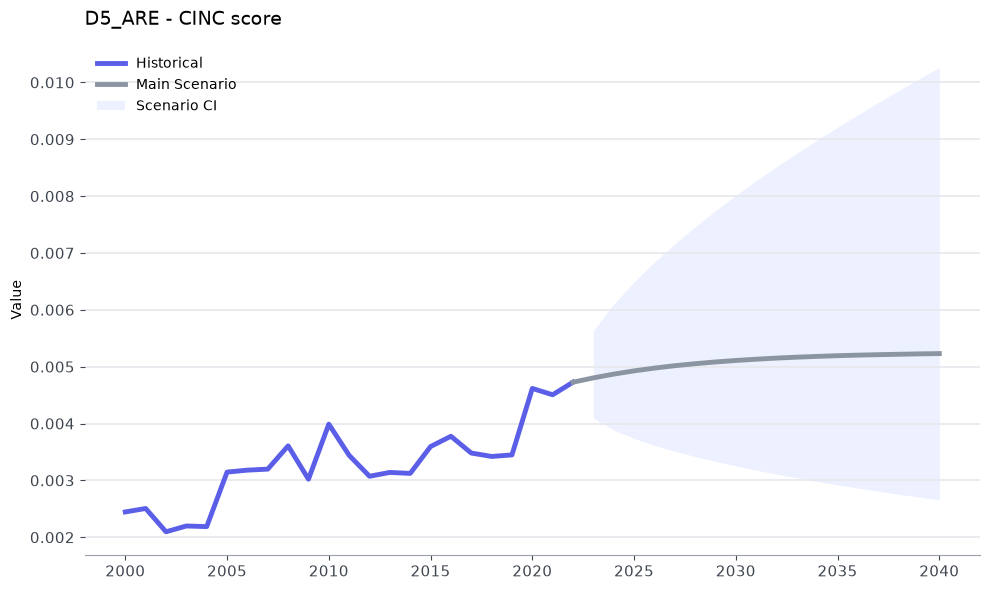

In [18]:
import matplotlib.pyplot as plt

# Change these inputs to inspect one proxy path.
CHECK_PROXY_ID = "D5_ARE"
CHECK_SCENARIO = "main_scenario"  # main_scenario, optimistic_scenario, pessimistic_scenario

allowed_future_scenarios = {"main_scenario", "optimistic_scenario", "pessimistic_scenario"}
if CHECK_SCENARIO not in allowed_future_scenarios:
    raise ValueError(f"CHECK_SCENARIO must be one of {sorted(allowed_future_scenarios)}")

plot_df = full_data_to_2040[full_data_to_2040["proxy_id"] == CHECK_PROXY_ID].copy()
if plot_df.empty:
    raise ValueError(f"No rows found for proxy_id={CHECK_PROXY_ID!r}")

history_plot = plot_df[plot_df["scenario"] == "historical"].sort_values("year")
future_plot = plot_df[plot_df["scenario"] == CHECK_SCENARIO].sort_values("year")
if future_plot.empty:
    raise ValueError(f"No {CHECK_SCENARIO!r} rows found for proxy_id={CHECK_PROXY_ID!r}")

line_future = pd.concat([history_plot.tail(1), future_plot], ignore_index=True)
label_text = str(plot_df["labels"].dropna().iloc[0]) if plot_df["labels"].notna().any() else CHECK_PROXY_ID

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    history_plot["year"], history_plot["value"],
    color="#5B5FE8", linewidth=3.5, label="Historical",
)
ax.plot(
    line_future["year"], line_future["value"],
    color="#8B95A1", linewidth=3.5, label=CHECK_SCENARIO.replace("_", " ").title(),
)

ci_rows = future_plot.dropna(subset=["lower_ci", "upper_ci"])
if not ci_rows.empty:
    ax.fill_between(
        ci_rows["year"].to_numpy(dtype=float),
        ci_rows["lower_ci"].to_numpy(dtype=float),
        ci_rows["upper_ci"].to_numpy(dtype=float),
        color="#DDE4FF", alpha=0.55, linewidth=0, label="Scenario CI",
    )

ax.set_title(f"{CHECK_PROXY_ID} - {label_text}", loc="left", fontsize=14, pad=14)
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.grid(axis="y", color="#E6E8EC", linewidth=1.2)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#9AA1AA")
ax.tick_params(axis="both", labelsize=11, colors="#3F4650")
ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()